### <div style= 'color: goldenrod'> Import all the required modules

In [2]:
import os
import re
import torch
import glob

import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib widget

### <div style= 'color: yellow'>Model Definition

In [3]:
# ==========================================================
# Single Residual Network Block
# ==========================================================
class ResNetBlock(nn.Module):
    def __init__(self, hidden_dim, auxiliary_dim=1):
        super().__init__()
        # We accept the hidden state + the auxiliary Central Pressure injection
        self.fc = nn.Linear(hidden_dim + auxiliary_dim, hidden_dim)
        self.act = nn.GELU() # Gaussian Error Linear Unit
    
    def forward(self, x, cp):
        # Concatenate Central Pressure to the input of the layer
        combined = torch.cat([x, cp], dim=1)
        out = self.act(self.fc(combined))
        return x + out # Residual connection

# ==========================================================
# Set up the Residual Network flow
# ==========================================================
class PhysicsEmulator(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=512): 
        super().__init__()
        # Separate EOS inputs from Central Pressure
        # input_dim is 8: (7 EOS params + 1 Central Pressure)
        self.eos_dim = input_dim - 1 
        
        # 1. Initial encoding of EOS parameters only: 
        self.input_layer = nn.Linear(self.eos_dim, hidden_dim)
        
        # 2. Deep Residual Layers with Central Pressure Injection
        self.block1 = ResNetBlock(hidden_dim, auxiliary_dim=1)
        self.block2 = ResNetBlock(hidden_dim, auxiliary_dim=1)
        self.block3 = ResNetBlock(hidden_dim, auxiliary_dim=1)
        self.block4 = ResNetBlock(hidden_dim, auxiliary_dim=1)

        # 3. Output layers
        self.final_layer = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim // 2), # Inject Central Pressure one last time
            nn.GELU(),                                      # 513 --> 256
            nn.Linear(hidden_dim // 2, 3)                   # Output: 256 --> 3
        )
        
    def forward(self, x):
        # Split input into EOS params and Central Pressure
        # Central Pressure is the LAST column (index -1)
        eos_params = x[:, :-1]
        cp = x[:, -1:]
        
        # 1. Encode EOS
        x_hidden = self.input_layer(eos_params)           # Input: 7 --> 512

        # 2. Central Pressure-Injected Residual Flow: Pass through blocks, injecting Central Pressure at each step
        x_hidden = self.block1(x_hidden, cp)              # 512 + 1 --> 512
        x_hidden = self.block2(x_hidden, cp)              # 512 + 1 --> 512
        x_hidden = self.block3(x_hidden, cp)              # 512 + 1 --> 512
        x_hidden = self.block4(x_hidden, cp)              # 512 + 1 --> 512
        
        # 3. Final Prediction
        # Concatenate Central Pressure one last time for the read-out
        combined_final = torch.cat([x_hidden, cp], dim=1) # 512 + 1 = 513
        return self.final_layer(combined_final)             

### <div style= 'color: yellow'> Testing the model on Unseen files

Total files available: 399755
Length of training set: 399700
Total unseen files available for testing: 55
MR plot   : 10 unseen files
TD plot   : 1 unseen files
Using saved normalization statistics.


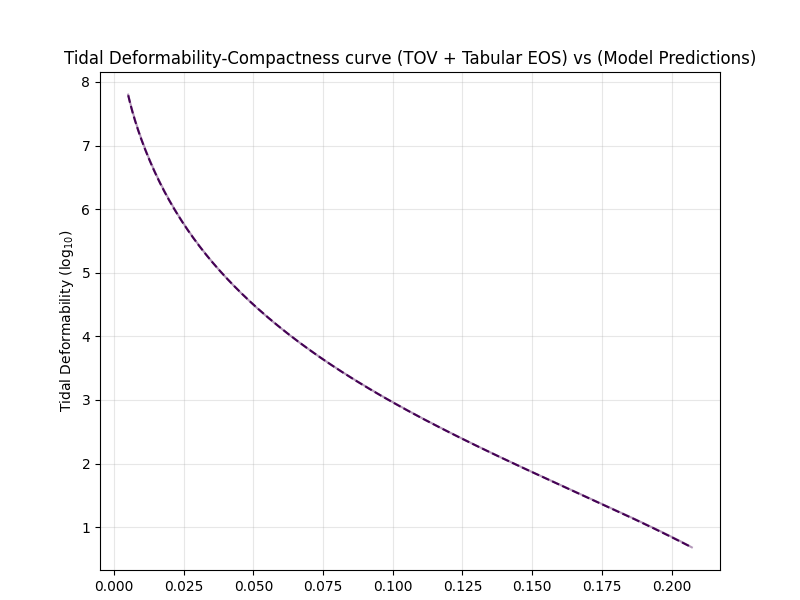

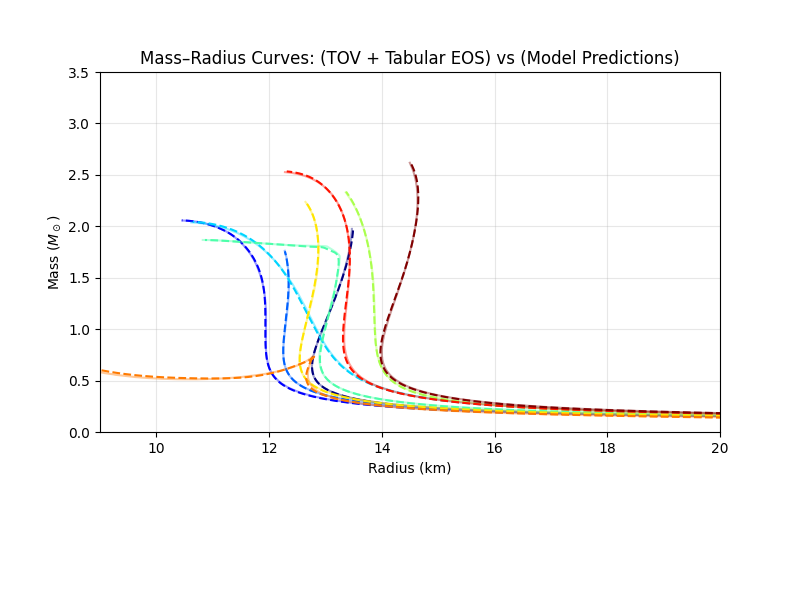

In [6]:
# ==========================================================
# 1. Configuration and constants
# ==========================================================
NUM_FILES_TO_USE = 399700 # Out of 399755 
# The rest is used as "unseen" data to test the trained model

DATA_DIR_PATH = "/home/kay/ML-for-Neutron-Stars/All_MR_Relations/All_MR_Relations/"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

save_dir_dataset = f"/home/kay/Master-Thesis/ResNet_Tabular(EOS+CP)_MRTD_Emulator/Datasets/{NUM_FILES_TO_USE}files"
save_dir_outputs = f"/home/kay/Master-Thesis/ResNet_Tabular(EOS+CP)_MRTD_Emulator/Cluster_Output/{NUM_FILES_TO_USE}files"
save_dir_testing = f"/home/kay/Master-Thesis/ResNet_Tabular(EOS+CP)_MRTD_Emulator/Testing/{NUM_FILES_TO_USE}files"

RADIUS_SCALE = 25.0
MASS_SCALE = 3.5

# How many unseen EOS to plot
N_MR_FILES = 10         # for Mass–Radius plot <--------------------------------
N_TD_FILES = 1          # for Compactness–Tidal plot <--------------------------

MODEL_NO = 4            # For saving plots <------------------------------------

# ==========================================================
# 2. Define function to extract EOS paramters from a file
# ==========================================================
def extract_eos_params(filename):
    match = pattern.match(filename)
    if not match:
        return None
    
    # Extract raw values exactly like training
    m = float(match.group("m")) / 100.0
    L = float(match.group("L"))
    J = float(match.group("J"))
    n_v = float(match.group("n_v"))
    d = float(match.group("d"))
    B = float(match.group("B")) / 1000.0
    n = float(match.group('n')) / 1000.0  # e.g., 0.160
    
    # Return as a numpy array for easy stacking [m, L, J, n_v, d, B, n]
    return np.array([m, L, J, n_v, d, B, n], dtype=np.float32)

# ==========================================================
# 3. Filter out the unseen files
# ==========================================================
# Regex must match the Training Pipeline exactly
pattern = re.compile(
    r"MREoSm(?P<m>\d+)"
    r"L(?P<L>\d+)"
    r"J(?P<J>\d+)"
    r"T(?P<T>\d+)_"
    r"n(?P<n>\d+)_"
    r"Yp?\+.*?RGgen_"
    r"v(?P<n_v>[-\d\.]+)"
    r"d(?P<d>[-\d\.]+)"
    r"B(?P<Btype>[np])(?P<B>\d+)\.dat"
)

# ==============================================================================
# 4. Select Unseen files and extract the input at output paramters
# ==============================================================================
# Path to data
all_files = glob.glob(os.path.join(DATA_DIR_PATH, "MR*.dat"))
print("Total files available:", len(all_files))

# 4.1. Load the list of files used for training
# Ensure this file exists from the training run!
try:
    training_files_used = np.load(os.path.join(save_dir_dataset, "files_used_for_training.npy"), allow_pickle=True)
    # Convert to set for fast lookup
    training_set = {
    os.path.basename(f) for f in training_files_used        
    }
    print("Length of training set:", len(training_set))
except FileNotFoundError:
    print("Warning: List of training files not found. Using random files (risk of data leakage).")
    training_set = {
    os.path.basename(f) for f in training_files_used        
    }
    print("Length of random training set:", len(training_set))

# 4.2. Filter: Keep only files NOT in the training set
test_pool = [
    f for f in all_files
    if os.path.basename(f) not in training_set
]
print("Total unseen files available for testing:", len(test_pool))

# 4.3. Ensure we have enough unseen files
if len(test_pool) < max(N_MR_FILES, N_TD_FILES):
    raise RuntimeError("Not enough unseen files available.")

# 4.4. Select the required number of files for the M-R plot randomly
selected_files_MR = np.random.choice(
    test_pool, size=N_MR_FILES, replace=False
)

# 4.4. Select the required number of files for the TD-C plot randomly
selected_files_TD = np.random.choice(
    test_pool, size=N_TD_FILES, replace=False
)

print(f"MR plot   : {len(selected_files_MR)} unseen files")
print(f"TD plot   : {len(selected_files_TD)} unseen files")

# ==============================================================================
# 5. Prepare model and scalars
# ==============================================================================
# Load Model and call to device
model = PhysicsEmulator(input_dim=8).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(save_dir_outputs, "Best_EOS_Model.pth"), map_location=DEVICE))
model.eval()    # Set model in evaluation mode

# Load the means and stds for normalization from training
if 'X_eos_mean' not in locals():
    # Loading the SAME mean/std from TRAINING.
    X_eos_mean = torch.load(os.path.join(save_dir_outputs, "X_eos_mean.pt"), map_location=DEVICE)
    X_eos_std = torch.load(os.path.join(save_dir_outputs, "X_eos_std.pt"), map_location=DEVICE)
    print("Using saved normalization statistics.")
else:
    raise RuntimeError("Normalization statistics not found.")

# ==============================================================================
# 6. Evaluation and plot loop
# ==============================================================================
fig1, ax1 = plt.subplots(figsize=(8, 6))
fig2, ax2 = plt.subplots(figsize=(8, 6))

# ------------------------------------------------------------------------------
# M-R plot loop
# ------------------------------------------------------------------------------

colors_MR = plt.cm.jet(np.linspace(0, 1, len(selected_files_MR)))

for color, file_path in zip(colors_MR, selected_files_MR):
    # 1. Extract all EOS parameters from the chosen files
    filename = os.path.basename(file_path)
    eos_params = extract_eos_params(filename)
    if eos_params is None:
        continue

    # load data
    try:
        data = np.loadtxt(file_path)
    except Exception:
        continue

    # 2. Get cp, mass and radius values from within the file
    cp_vals     = data[:, 0]    
    mass_vals   = data[:, 1]
    radius_vals = data[:, 2]

    # 3. Fix to only use stable branch up to M_max - 2 points
    max_m_idx = np.argmax(mass_vals)
    cut_idx = max(1, max_m_idx - 2)
    cp_vals     = cp_vals[:cut_idx]
    mass_vals   = mass_vals[:cut_idx]
    radius_vals = radius_vals[:cut_idx]

    # 4. No Minimmum mass cutoff

    # 5. Basic filtering to ensure positive values
    valid_mask = (radius_vals > 0) & (mass_vals > 0)
    cp_vals     = cp_vals[valid_mask]
    mass_vals   = mass_vals[valid_mask]
    radius_vals = radius_vals[valid_mask]

    # 6. Prepare input tensors
    # 6.1. Tile the EOS params for every mass point
    num_points = len(mass_vals)
    eos_repeated = np.tile(eos_params, (num_points, 1))

    # 6.2. Convert to Tensor
    X_eos_input  = torch.tensor(eos_repeated, dtype=torch.float32, device=DEVICE)
    X_cp_input = torch.tensor(cp_vals[:, None], dtype=torch.float32, device=DEVICE)

    # 6.3. Normalize using training statistics
    # EOS: Z-score
    X_eos_norm  = (X_eos_input - X_eos_mean) / X_eos_std
    # CP: Log Scaling
    X_cp_norm = torch.log10(X_cp_input)

    # 6.4. Concatenate inputs
    model_input = torch.cat((X_eos_norm, X_cp_norm), dim=1)

    # 7. Predict and denormalize
    with torch.no_grad():
        pred = model(model_input)
        M_pred = (pred[:, 0] * MASS_SCALE).cpu().numpy()
        R_pred_km = (pred[:, 1] * RADIUS_SCALE).cpu().numpy()

    # Label for plotting
    label = (
        f"m={eos_params[0]:.2f}, L={eos_params[1]:.0f}, "
        f"J={eos_params[2]:.0f}, n_v={eos_params[3]:.2f},"
        f"d={eos_params[4]:.2f}, B={eos_params[5]:.3f}, "
        f"n={eos_params[6]:.3f}, cp = {cp_vals[0]:.2f}"
    )

    # 8. M-R Plot
    ax1.plot(radius_vals, mass_vals, "-", color=color, alpha=0.4)
    ax1.plot(R_pred_km, M_pred, "--", color=color, label=label)

    # Formatting Plot1
    ax1.set_title("Mass–Radius Curves: (TOV + Tabular EOS) vs (Model Predictions)")
    ax1.set_xlabel("Radius (km)")
    ax1.set_ylabel(r"Mass ($M_\odot$)")
    ax1.set_xlim(9, 20)
    ax1.set_ylim(0, 3.5)
    ax1.grid(alpha=0.3)


# ------------------------------------------------------------------------------
# TD-C plot loop
# ------------------------------------------------------------------------------
colors_TD = plt.cm.viridis(np.linspace(0, 1, len(selected_files_TD)))

for color, file_path in zip(colors_TD, selected_files_TD):
    # 1. Extract all EOS parameters from the chosen files
    filename = os.path.basename(file_path)
    eos_params = extract_eos_params(filename)
    if eos_params is None:
        continue

    # load data
    try:
        data = np.loadtxt(file_path)
    except Exception:
        continue

    # 2. Get cp, mass, radius and tidal deformability values from within the file
    cp_vals     = data[:, 0]
    mass_vals   = data[:, 1]
    radius_vals = data[:, 2]
    td_vals     = data[:, 3]

    # 3. Fix to only use stable branch up to M_max - 2 points
    max_m_idx = np.argmax(mass_vals)
    cut_idx = max(1, max_m_idx - 2)
    cp_vals     = cp_vals[:cut_idx]
    mass_vals   = mass_vals[:cut_idx]
    radius_vals = radius_vals[:cut_idx]
    td_vals     = td_vals[:cut_idx]

    # 4. No Minimmum mass cutoff

    # 5. Basic filtering to ensure positive values
    valid_mask = (radius_vals > 0) & (mass_vals > 0)
    cp_vals     = cp_vals[valid_mask]
    mass_vals   = mass_vals[valid_mask]
    radius_vals = radius_vals[valid_mask]
    td_vals     = td_vals[valid_mask]

    # 6. Prepare input tensors
    # 6.1. Tile the EOS params for every mass point
    num_points = len(mass_vals)
    eos_repeated = np.tile(eos_params, (num_points, 1))

    # 6.2. Convert to Tensor
    X_eos_input  = torch.tensor(eos_repeated, dtype=torch.float32, device=DEVICE)
    X_cp_input   = torch.tensor(cp_vals[:, None], dtype=torch.float32, device=DEVICE)

    # 6.3. Normalize using training statistics
    # EOS: Z-score
    X_eos_norm  = (X_eos_input - X_eos_mean) / X_eos_std
    # CP: Log Scaling
    X_cp_norm   = torch.log10(X_cp_input)

    # 6.4. Concatenate inputs
    model_input = torch.cat((X_eos_norm, X_cp_norm), dim=1)

    # 7. Predict and denormalize
    with torch.no_grad():
        pred = model(model_input)
        M_pred = (pred[:, 0] * MASS_SCALE).cpu().numpy()
        R_pred_km = (pred[:, 1] * RADIUS_SCALE).cpu().numpy()
        td_pred   = (10 ** pred[:, 2]).cpu().numpy()

    # 8. Calculate compactness
    compact_truth = mass_vals / radius_vals
    compact_pred  = M_pred / R_pred_km

    # 9. TD-C Plot
    ax2.plot(compact_truth, np.log10(td_vals), "-", color=color, alpha=0.4,
             label = "TOV + Tabular EOS")
    ax2.plot(compact_pred,  np.log10(td_pred), "--", color=color,
             label = f"Model Prediction: {label}")


    # Formatting Plot2
    ax2.set_title("Tidal Deformability-Compactness curve (TOV + Tabular EOS) vs (Model Predictions)")
    ax2.set_xlabel(r"Compactness ($M/R$)")
    ax2.set_ylabel("Tidal Deformability (log$_{10}$)")
    ax2.grid(alpha=0.3)

# Legend Plot1
fig1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    fontsize="small",
    ncol=2
)
fig1.subplots_adjust(bottom=0.28)

# Legend Plot2
fig2.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    fontsize="small",
    ncol=2
)
fig2.subplots_adjust(bottom=0.05)

# Save both the plots
os.makedirs(save_dir_testing, exist_ok=True)
fig1.savefig(os.path.join(save_dir_testing, f"MR_unseen_{MODEL_NO}.svg"), bbox_inches="tight")
fig2.savefig(os.path.join(save_dir_testing, f"TD_compactness_unseen_{MODEL_NO}.svg"), bbox_inches="tight")

plt.show()

### <div style= 'color: yellow'> Model Metrics

In [8]:
# All original values
orig_mass_all = mass_vals
orig_radius_all = radius_vals
orig_td_all = td_vals

# All predicted values
pred_mass_all = M_pred
pred_radius_all = R_pred_km
pred_td_all = td_pred

# Mass Metrics
mae_mass = mean_absolute_error(orig_mass_all, pred_mass_all)
rmse_mass = np.sqrt(mean_squared_error(orig_mass_all, pred_mass_all))
r2_mass = r2_score(orig_mass_all, pred_mass_all)

# Radius Metrics
mae_radius = mean_absolute_error(orig_radius_all, pred_radius_all)
rmse_radius = np.sqrt(mean_squared_error(orig_radius_all, pred_radius_all))
r2_radius = r2_score(orig_radius_all, pred_radius_all)

# TD Metrics
mae_td = mean_absolute_error(np.log10(orig_td_all), np.log10(pred_td_all))
rmse_td = np.sqrt(mean_squared_error(np.log10(orig_td_all), np.log10(pred_td_all)))
r2_td = r2_score(orig_td_all, pred_td_all)

# Normalized MSE of the model for all three parameters combined
norm_rmse = np.mean([
    rmse_radius / np.mean(orig_radius_all),
    rmse_mass / np.mean(orig_mass_all),
    rmse_td / np.mean(orig_td_all)
])

print(f"Radius:  MAE={mae_radius:.4f}, RMSE={rmse_radius:.4f}, R²={r2_radius:.4f}")
print(f"Mass: MAE={mae_mass:.4f}, RMSE={rmse_mass:.4f}, R²={r2_mass:.4f}")
print(f"Tidal Deformability: MAE={mae_td:.4f}, RMSE={rmse_td:.4f}, R²={r2_td:.4f}")
print(f"Combined normalized RMSE = {norm_rmse:.4f}")

Radius:  MAE=0.0178, RMSE=0.0430, R²=0.9998
Mass: MAE=0.0015, RMSE=0.0017, R²=1.0000
Tidal Deformability: MAE=0.0011, RMSE=0.0015, R²=0.9998
Combined normalized RMSE = 0.0015


In [ ]:
# ==========================================================
# Save Metrics to a Text file
# ==========================================================
output_file = os.path.join(save_dir_testing, f"Model_metrics_{MODEL_NO}.txt")

with open(output_file, "w") as f:
    f.write("Mass, Radius and TD prediction metrics\n")
    f.write("======================================\n")

    f.write("Mass Prediction Metrics:\n")
    f.write(f"MAE   : {mae_mass:.6f}\n")
    f.write(f"RMSE  : {rmse_mass:.6f}\n")
    f.write(f"R^2   : {r2_mass:.6f}\n")
    f.write("\n")

    f.write("Radius Prediction Metrics:\n")
    f.write(f"MAE   : {mae_radius:.6f}\ n")
    f.write(f"RMSE  : {rmse_radius:.6f}\n")
    f.write(f"R^2   : {r2_radius:.6f}\n")
    f.write("\n")

    f.write("Tidal Deformability Prediction Metrics:\n")
    f.write(f"MAE   : {mae_td:.6f}\n")
    f.write(f"RMSE  : {rmse_td:.6f}\n")
    f.write(f"R^2   : {r2_td:.6f}\n")
    f.write("\n")

    f.write(f"Norm RMSE : {norm_rmse:.6f}\n")

print(f"Metrics saved to {output_file}")


Metrics saved to /home/kay/Master-Thesis/ResNet_Tabular(EOS+CP)_MRTD_Emulator/Testing/399700files/Model_metrics_delete_4.txt


### <div style= 'color: yellow'> Testing model on Jan-Erik's new file with different step size for input paramter B

Testing on 1 unseen files.
Processing file: MREoSm60L45J30T0_n160_Yp0f+RGgen_v1.00d1.90B73.dat
EOS params: 7
Data loaded!


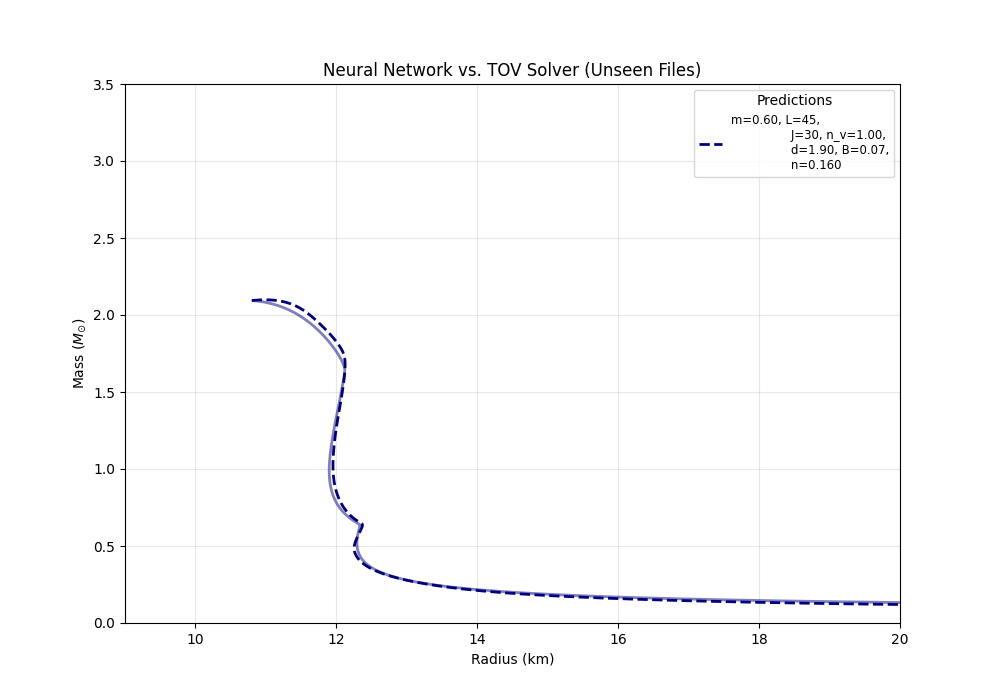

In [ ]:
# ==============================================================================
# 1. CONFIGURATION & HELPERS
# ==============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RADIUS_SCALE = 25.0
MASS_SCALE = 3.5

# ==========================================================
# 2. Define function to extract EOS paramters from a file
# ==========================================================
def extract_eos_params(filename):
    match = pattern.match(filename)
    if not match:
        return None
    
    # Extract raw values exactly like training
    m = float(match.group("m")) / 100.0
    L = float(match.group("L"))
    J = float(match.group("J"))
    n_v = float(match.group("n_v"))
    d = float(match.group("d"))
    B = float(match.group("B")) / 1000.0
    n = float(match.group('n')) / 1000.0  # e.g., 0.160
    
    # Return as a numpy array for easy stacking [m, L, J, n_v, d, B, n]
    return np.array([m, L, J, n_v, d, B, n], dtype=np.float32)

# ==========================================================
# 3. Filter out the unseen files
# ==========================================================
# Regex must match the Training Pipeline exactly
pattern = re.compile(
    r"MREoSm(?P<m>\d+)"
    r"L(?P<L>\d+)"
    r"J(?P<J>\d+)"
    r"T(?P<T>\d+)_"
    r"n(?P<n>\d+)_"
    r"Yp0f?\+.*?RGgen_"
    r"v(?P<n_v>[-\d\.]+)"
    r"d(?P<d>[-\d\.]+)"
    r"B(?:(?P<Btype>[np]))?(?P<B>\d+)\.dat"
)

# ==============================================================================
# 4. Select Unseen files and extract the input at output paramters
# ==============================================================================
# Path to data
DATA_DIR_PATH = "/home/kay/ML-for-Neutron-Stars/New files"

selected_files = glob.glob(os.path.join(DATA_DIR_PATH, "MR*.dat"))
print(f"Testing on {len(selected_files)} unseen files.")

# ==============================================================================
# 5. Prepare model and scalars
# ==============================================================================
# Load Model and call to device
model = PhysicsEmulator(input_dim=8).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(save_dir_outputs, "Best_EOS_Model.pth"), map_location=DEVICE))
model.eval() # Put model in evaluation mode

# Load the means and stds for normalization from training
if 'X_eos_mean' not in locals():
        # Loading the SAME mean/std from TRAINING.
    X_eos_mean = torch.load(os.path.join(save_dir_outputs, "X_eos_mean.pt"), map_location=DEVICE)
    X_eos_std = torch.load(os.path.join(save_dir_outputs, "X_eos_std.pt"), map_location=DEVICE)
    print("ERROR: X_eos_mean and X_eos_std are missing!")
    print("You must save these during training or run this cell in the same notebook.")
else:
    X_eos_mean = X_eos_mean.to(DEVICE)
    X_eos_std = X_eos_std.to(DEVICE)

# ==============================================================================
# 4. Evaluation and plot loop
# ==============================================================================
plt.figure(figsize=(10, 7))
colors = plt.cm.jet(np.linspace(0, 1, len(selected_files)))

for color, file_path in zip(colors, selected_files):
    # 1. Extract all EOS parameters from the chosen files
    filename = os.path.basename(file_path)
    print("Processing file:", filename)
    eos_params = extract_eos_params(filename)
    print("EOS params:", len(eos_params) if eos_params is not None else "None")
    
    if eos_params is None: continue

    # Load Data
    try:
        data = np.loadtxt(file_path)
        print("Data loaded!")
    except: continue
        
    # 2. Get cp, mass and radius values from within the file
    mass_vals = data[:, 1]
    radius_vals = data[:, 2]
    cp_vals = data[:, 0]

    # 3. Filter stable branch (Up to Max Mass) same as training
    max_m_idx = np.argmax(mass_vals)
    # Apply the same safety margin cut as training
    SAFETY_MARGIN = 2
    cut_idx = max(1, max_m_idx - SAFETY_MARGIN) 
    mass_vals = mass_vals[:cut_idx]
    radius_vals = radius_vals[:cut_idx]
    cp_vals = cp_vals[:cut_idx]

    # 4. No Minimmum mass cutoff

    # 5. Basic filtering to ensure positive values
    positive_mask = (mass_vals > 0) & (radius_vals > 0)
    mass_vals = mass_vals[positive_mask]
    radius_vals = radius_vals[positive_mask]
    cp_vals = cp_vals[positive_mask]

    # 6. Prepare input tensors
    # 6.1. Tile the EOS params for every mass point
    num_points = len(mass_vals)
    eos_repeated = np.tile(eos_params, (num_points, 1)) # Shape (N, 7)
    
    # 6.2. Convert to Tensor
    X_eos_input = torch.tensor(eos_repeated, dtype=torch.float32).to(DEVICE)
    X_cp_input = torch.tensor(cp_vals.reshape(-1, 1), dtype=torch.float32).to(DEVICE)
    
    # 6.3. Normalize using training statistics
    # EOS: Z-score
    X_eos_norm = (X_eos_input - X_eos_mean) / X_eos_std
    # CP: Log10 Scaling
    X_cp_norm   = torch.log10(X_cp_input)
    
    # 6.4. Concatenate Inputs
    model_input = torch.cat((X_eos_norm, X_cp_norm), dim=1)
    
    # 7. Predict and denormalize
    with torch.no_grad():
        # Predict normalized Mass and Radius (0.0 to ~1.0)
        pred = model(model_input)
        Mass_pred_norm = pred[:, 0:1]
        R_pred_norm = pred[:, 1:2]

        # De-normalize
        R_pred = R_pred_norm * RADIUS_SCALE
        Mass_pred = Mass_pred_norm * MASS_SCALE
        
        # Move to CPU for plotting
        Mass_pred = Mass_pred.cpu().numpy().flatten()
        R_pred= R_pred.cpu().numpy().flatten()

    # 9. Plotting
    label_txt = f"""m={eos_params[0]:.2f}, L={eos_params[1]:.0f}, 
                J={eos_params[2]:.0f}, n_v={eos_params[3]:.2f},
                d={eos_params[4]:.2f}, B={eos_params[5]:.2f},
                n={eos_params[6]:.3f}""" 
    
    # Plot Original values
    plt.plot(radius_vals, mass_vals, "-", color=color, alpha=0.5, linewidth=2)
    
    # Plot Prediction 
    plt.plot(R_pred, Mass_pred, "--", color=color, linewidth=2, label=label_txt)
 
plt.title("Neural Network vs. TOV Solver (Unseen Files)")
plt.xlabel("Radius (km)")
plt.ylabel(r"Mass ($M_{\odot}$)")
plt.legend(title="Predictions", fontsize='small')
plt.grid(True, alpha=0.3)
plt.xlim(9, 20)
plt.ylim(0, 3.5)
# plt.savefig(os.path.join(save_dir_testing, "Testing plot B.png"))

plt.show()

In [11]:
# All original values
orig_mass_all = mass_vals
orig_radius_all = radius_vals

# All predicted values
pred_mass_all = Mass_pred
pred_radius_all = R_pred

# Mass metrics
mae_mass = mean_absolute_error(orig_mass_all, pred_mass_all)
rmse_mass = np.sqrt(mean_squared_error(orig_mass_all, pred_mass_all))
r2_mass = r2_score(orig_mass_all, pred_mass_all)

# radius Metrics
mae_radius = mean_absolute_error(orig_radius_all, pred_radius_all)
rmse_radius = np.sqrt(mean_squared_error(orig_radius_all, pred_radius_all))
r2_radius = r2_score(orig_radius_all, pred_radius_all)

# Normalized MSE of the model for all three parameters combined
norm_rmse = np.mean([
    rmse_radius / np.mean(orig_radius_all),
    rmse_mass / np.mean(orig_mass_all),
])

print(f"Radius:  MAE={mae_radius:.4f}, RMSE={rmse_radius:.4f}, R²={r2_radius:.4f}")
print(f"Mass:  RMSE={rmse_mass:.4f}, R²={r2_mass:.4f}")
print(f"Combined normalized RMSE = {norm_rmse:.4f}")

Radius:  MAE=1.7887, RMSE=8.1282, R²=0.5707
Mass:  RMSE=0.0181, R²=0.9993
Combined normalized RMSE = 0.2642
